# Who Pollutes, Who Pays?
## Data Preprocessing & Integration Notebook

**Central question:** Do wealthier nations systematically emit more GHG per capita? And are low-emission countries genuinely sustainable, or is their low footprint a consequence of limited energy access?

**Datasets:**
1. `OECD GHG Emissions`: GHG per capita (kg CO₂-eq/person), 99 countries, 1988–2023  
2. `World Bank Economy & Growth`: GDP per capita (PPP, current intl $), 265 countries, 1960–2023
3. `World Bank Energy & Mining`: Renewable energy share (%), electricity access (%), 265 countries, 1960–2023 
4. `World Bank Population`: Total population (persons), 265 countries, 1960–2023

**Join key:** ISO-3 country code  
**Analysis window:** 2014–2023 (overlap of all three datasets)

## 0. Setup & Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

## 1. Load Raw Datasets

In [16]:
# OECD GHG Emissions 
GHG_PATH = 'data/OECD.csv'

ghg_raw = pd.read_csv(GHG_PATH)
print(f'GHG raw shape: {ghg_raw.shape}')
print(f'Columns: {ghg_raw.columns.tolist()}')
ghg_raw.head(3)

GHG raw shape: (2723, 30)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'POLLUTANT', 'Pollutant', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'PRICE_BASE', 'Price base', 'BASE_PER', 'Base period', 'DECIMALS', 'Decimals', 'CONVERSION_TYPE', 'Conversion type']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,POLLUTANT,Pollutant,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,DECIMALS,Decimals,CONVERSION_TYPE,Conversion type
0,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUS,Australia,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,19.93,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
1,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUT,Austria,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,7.52,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
2,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,BEL,Belgium,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,8.39,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN


In [17]:
# World Bank Economy & Growth
eco_raw = pd.read_csv('data/economy-and-growth-2025.csv')
print(f'Economy raw shape: {eco_raw.shape}')
print(f'Year range: {eco_raw["Year"].min()} – {eco_raw["Year"].max()}')
eco_raw.head(3)

Economy raw shape: (16852, 256)
Year range: 1960 – 2025


,Country Name,Country Code,Year,average_value_Adjusted net national income (annual % growth),average_value_Adjusted net national income (constant 2015 US$),average_value_Adjusted net national income (current US$),average_value_Adjusted net national income per capita (annual % growth),average_value_Adjusted net national income per capita (constant 2015 US$),average_value_Adjusted net national income per capita (current US$),"average_value_Adjusted net savings, excluding particulate emission damage (% of GNI)","average_value_Adjusted net savings, excluding particulate emission damage (current US$)","average_value_Adjusted net savings, including particulate emission damage (% of GNI)","average_value_Adjusted net savings, including particulate emission damage (current US$)",average_value_Adjusted savings: carbon dioxide damage (% of GNI),average_value_Adjusted savings: carbon dioxide damage (current US$),...,average_value_Taxes less subsidies on products (current LCU),average_value_Taxes less subsidies on products (current US$),"average_value_Technical cooperation grants (BoP, current US$)",average_value_Terms of trade adjustment (constant LCU),average_value_Textiles and clothing (% of value added in manufacturing),average_value_Total debt service (% of GNI),"average_value_Total debt service (% of exports of goods, services and primary income)","average_value_Total reserves (includes gold, current US$)",average_value_Total reserves minus gold (current US$),average_value_Trade (% of GDP),average_value_Trade in services (% of GDP),"average_value_Transport services (% of service exports, BoP)","average_value_Transport services (% of service imports, BoP)","average_value_Travel services (% of service exports, BoP)","average_value_Travel services (% of service imports, BoP)"
0,Aruba,ABW,1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216454.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232581.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289074.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# World Bank Energy & Mining 
nrg_raw = pd.read_csv('data/energy-and-mining-2025.csv')
print(f'Energy raw shape: {nrg_raw.shape}')
print(f'Year range: {nrg_raw["Year"].min()} – {nrg_raw["Year"].max()}')
nrg_raw.head(3)

Energy raw shape: (15521, 44)
Year range: 1960 – 2025


,Country Name,Country Code,Year,average_value_Access to electricity (% of population),"average_value_Access to electricity, rural (% of rural population)","average_value_Access to electricity, urban (% of urban population)",average_value_Adjusted savings: energy depletion (% of GNI),average_value_Adjusted savings: energy depletion (current US$),average_value_Adjusted savings: mineral depletion (% of GNI),average_value_Adjusted savings: mineral depletion (current US$),average_value_Adjusted savings: natural resources depletion (% of GNI),average_value_Alternative and nuclear energy (% of total energy use),average_value_Combustible renewables and waste (% of total energy),average_value_Electric power consumption (kWh per capita),average_value_Electric power transmission and distribution losses (% of output),...,average_value_Fuel exports (% of merchandise exports),average_value_Fuel imports (% of merchandise imports),average_value_GDP per unit of energy use (PPP $ per kg of oil equivalent),average_value_GDP per unit of energy use (constant 2021 PPP $ per kg of oil equivalent),average_value_Investment in energy with private participation (current US$),average_value_Mineral rents (% of GDP),average_value_Natural gas rents (% of GDP),average_value_Oil rents (% of GDP),average_value_Ores and metals exports (% of merchandise exports),average_value_Ores and metals imports (% of merchandise imports),average_value_Renewable electricity output (% of total electricity output),average_value_Renewable energy consumption (% of total final energy consumption),average_value_Time to obtain an electrical connection (days),average_value_Total natural resources rents (% of GDP),average_value_Value lost due to electrical outages (% of sales for affected firms)
0,Aruba,ABW,1970,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1971,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1972,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean OECD GHG Dataset

**Key choices:**
- Keep only `MEASURE == '_T'` (total emissions excl. LULUCF) and `UNIT_MEASURE == 'KG_CO2E_PS'` (kg CO₂-eq per person)
- Drop aggregate/supranational entities (EU27, OECD, etc.) --> they are not countries
- Rename columns to clean, short names
- Filter to 2014–2023 (the decade of interest)

In [19]:
# Supranational aggregates to exclude
AGGREGATES = {'EU27_2020', 'OECD', 'OECDA', 'OECDSO', 'OECDE'}

ghg = (
    ghg_raw
    # Keep only the per-capita total GHG measure
    .query("MEASURE == '_T' and UNIT_MEASURE == 'KG_CO2E_PS'")
    # Drop supranational aggregates
    .loc[lambda df: ~df['REF_AREA'].isin(AGGREGATES)]
    # Select and rename relevant columns
    [['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'REF_AREA': 'iso3',
        'Reference area': 'country_name_ghg',
        'TIME_PERIOD': 'year',
        'OBS_VALUE': 'ghg_per_capita'
    })
    # Filter to 2014–2023
    .query('year >= 2014 and year <= 2023')
    .dropna(subset=['ghg_per_capita'])
    .reset_index(drop=True)
)

print(f'GHG cleaned shape: {ghg.shape}')
print(f'Countries: {ghg["iso3"].nunique()}')
print(f'Years: {sorted(ghg["year"].unique())}')
ghg.head()

GHG cleaned shape: (789, 4)
Countries: 90
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,iso3,country_name_ghg,year,ghg_per_capita
0,AUS,Australia,2023,19.93
1,AUT,Austria,2023,7.52
2,BEL,Belgium,2023,8.39
3,CAN,Canada,2023,17.66
4,CZE,Czechia,2023,9.44


In [20]:
# Quick check: missing values
print('GHG missing values:')
print(ghg.isnull().sum())

# Summary stats
print('\nGHG per capita descriptive stats:')
print(ghg['ghg_per_capita'].describe())

GHG missing values:
iso3                0
country_name_ghg    0
year                0
ghg_per_capita      0
dtype: int64

GHG per capita descriptive stats:
count   789.00
mean      7.99
std       5.66
min       0.69
25%       4.49
50%       6.67
75%       9.79
max      33.77
Name: ghg_per_capita, dtype: float64


## 3. Clean World Bank Economy Dataset

**Key variable selected:** `GDP per capita, PPP (current international $)` —-> chosen over nominal GDP/capita because PPP adjusts for price-level differences, making cross-country comparisons more meaningful for living-standard analysis.

**Key choices:**
- Filter to 2014–2023 (overlap window)
- Drop World Bank regional/income-group aggregates (they share no ISO-3 code with GHG countries)
- Keep only rows with non-missing GDP per capita PPP

In [21]:
GDP_COL = 'average_value_GDP per capita, PPP (current international $)'

eco = (
    eco_raw
    [['Country Name', 'Country Code', 'Year', GDP_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        GDP_COL: 'gdp_per_capita_ppp'
    })
    .query('year >= 2014 and year <= 2023')
    .dropna(subset=['gdp_per_capita_ppp'])
    .reset_index(drop=True)
)

print(f'Economy cleaned shape: {eco.shape}')
print(f'Countries: {eco["iso3"].nunique()}')
print(f'Years: {sorted(eco["year"].unique())}')
eco.head()

Economy cleaned shape: (2467, 4)
Countries: 248
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,country_name_wb,iso3,year,gdp_per_capita_ppp
0,Aruba,ABW,2014,35657.29
1,Aruba,ABW,2015,35972.86
2,Aruba,ABW,2016,36117.54
3,Aruba,ABW,2017,37524.91
4,Aruba,ABW,2018,39287.06


In [22]:
print('Economy missing values after filter:')
print(eco.isnull().sum())
print('\nGDP per capita PPP stats:')
print(eco['gdp_per_capita_ppp'].describe())

Economy missing values after filter:
country_name_wb       0
iso3                  0
year                  0
gdp_per_capita_ppp    0
dtype: int64

GDP per capita PPP stats:
count     2467.00
mean     22913.72
std      23452.43
min        698.96
25%       5642.05
50%      14796.63
75%      32472.82
max     150508.22
Name: gdp_per_capita_ppp, dtype: float64


## 4. Clean World Bank Energy Dataset

**Key variables selected:**
- `Renewable energy consumption (% of total final energy consumption)` —-> proxy for clean energy transition
- `Access to electricity (% of population)` —-> proxy for energy poverty
- `Fossil fuel energy consumption (% of total)` —-> complementary to renewable share

Same temporal filter: 2014–2023.

In [23]:
RENEW_COL   = 'average_value_Renewable energy consumption (% of total final energy consumption)'
ELEC_COL    = 'average_value_Access to electricity (% of population)'
FOSSIL_COL  = 'average_value_Fossil fuel energy consumption (% of total)'

nrg = (
    nrg_raw
    [['Country Name', 'Country Code', 'Year', RENEW_COL, ELEC_COL, FOSSIL_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        RENEW_COL:  'renewable_pct',
        ELEC_COL:   'electricity_access_pct',
        FOSSIL_COL: 'fossil_fuel_pct'
    })
    .query('year >= 2014 and year <= 2023')
    .reset_index(drop=True)
)

print(f'Energy cleaned shape: {nrg.shape}')
print(f'Countries: {nrg["iso3"].nunique()}')
nrg.head()

Energy cleaned shape: (2647, 6)
Countries: 265


,country_name_wb,iso3,year,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,Aruba,ABW,2014,6.90,100.00,NaN
1,Aruba,ABW,2015,6.70,100.00,NaN
2,Aruba,ABW,2016,7.00,100.00,NaN
3,Aruba,ABW,2017,6.80,100.00,NaN
4,Aruba,ABW,2018,8.60,100.00,NaN


In [24]:
print('Energy missing values (per column):')
print(nrg.isnull().sum())
print()

# How many country-year pairs have at least one energy variable?
nrg_any = nrg.dropna(subset=['renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct'], how='all')
print(f'Country-year pairs with ≥1 energy value: {len(nrg_any)}')

Energy missing values (per column):
country_name_wb             0
iso3                        0
year                        0
renewable_pct             544
electricity_access_pct     17
fossil_fuel_pct           700
dtype: int64

Country-year pairs with ≥1 energy value: 2640


## 5. Add World Bank Region / Continent Metadata

The `continent` / macro-region variable is **not present in any raw dataset** and must be constructed externally.

We use the World Bank's official 7-region classification, embedded here as a static mapping to avoid any external API dependency. The mapping covers all ISO-3 codes present in the GHG dataset.

In [25]:
# World Bank 7-region classification (manually curated for GHG countries)
# Source: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519
WB_REGION = {
    # Europe & Central Asia
    'AUT': 'Europe & Central Asia', 'BEL': 'Europe & Central Asia',
    'CZE': 'Europe & Central Asia', 'DNK': 'Europe & Central Asia',
    'EST': 'Europe & Central Asia', 'FIN': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia', 'DEU': 'Europe & Central Asia',
    'GRC': 'Europe & Central Asia', 'HUN': 'Europe & Central Asia',
    'ISL': 'Europe & Central Asia', 'IRL': 'Europe & Central Asia',
    'ITA': 'Europe & Central Asia', 'LVA': 'Europe & Central Asia',
    'LTU': 'Europe & Central Asia', 'LUX': 'Europe & Central Asia',
    'NLD': 'Europe & Central Asia', 'NOR': 'Europe & Central Asia',
    'POL': 'Europe & Central Asia', 'PRT': 'Europe & Central Asia',
    'SVK': 'Europe & Central Asia', 'SVN': 'Europe & Central Asia',
    'ESP': 'Europe & Central Asia', 'SWE': 'Europe & Central Asia',
    'CHE': 'Europe & Central Asia', 'GBR': 'Europe & Central Asia',
    'AZE': 'Europe & Central Asia', 'BLR': 'Europe & Central Asia',
    'TUR': 'Europe & Central Asia',
    # North America
    'CAN': 'North America', 'MEX': 'North America', 'USA': 'North America',
    # Latin America & Caribbean
    'ARG': 'Latin America & Caribbean', 'BRB': 'Latin America & Caribbean',
    'CHL': 'Latin America & Caribbean', 'COL': 'Latin America & Caribbean',
    'CRI': 'Latin America & Caribbean',
    # East Asia & Pacific
    'AUS': 'East Asia & Pacific', 'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific', 'NZL': 'East Asia & Pacific',
    'BTN': 'East Asia & Pacific',
    # South Asia
    # (none in GHG sample)
    # Middle East & North Africa
    'ISR': 'Middle East & North Africa', 'DZA': 'Middle East & North Africa',
}

# Add missing countries to the World Bank region mapping
WB_REGION.update({
    # Europe & Central Asia
    'BGR': 'Europe & Central Asia',
    'HRV': 'Europe & Central Asia',
    'CYP': 'Europe & Central Asia',
    'GEO': 'Europe & Central Asia',
    'KAZ': 'Europe & Central Asia',
    'LIE': 'Europe & Central Asia',
    'MLT': 'Europe & Central Asia',
    'MDA': 'Europe & Central Asia',
    'MCO': 'Europe & Central Asia',
    'ROU': 'Europe & Central Asia',
    'RUS': 'Europe & Central Asia',
    'SRB': 'Europe & Central Asia',
    'UKR': 'Europe & Central Asia',
    'UZB': 'Europe & Central Asia',

    # Latin America & Caribbean
    'BRA': 'Latin America & Caribbean',
    'CUB': 'Latin America & Caribbean',
    'GTM': 'Latin America & Caribbean',
    'GUY': 'Latin America & Caribbean',
    'PAN': 'Latin America & Caribbean',
    'PER': 'Latin America & Caribbean',
    'URY': 'Latin America & Caribbean',
    'VEN': 'Latin America & Caribbean',

    # East Asia & Pacific
    'BRN': 'East Asia & Pacific',
    'CHN': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'MYS': 'East Asia & Pacific',
    'SGP': 'East Asia & Pacific',
    'SLB': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',

    # South Asia
    'IND': 'South Asia',
    'MDV': 'South Asia',
    'NPL': 'South Asia',

    # Middle East & North Africa
    'EGY': 'Middle East & North Africa',
    'IRQ': 'Middle East & North Africa',
    'LBN': 'Middle East & North Africa',
    'MAR': 'Middle East & North Africa',
    'SAU': 'Middle East & North Africa',

    # Sub-Saharan Africa
    'CIV': 'Sub-Saharan Africa',
    'GHA': 'Sub-Saharan Africa',
    'GNB': 'Sub-Saharan Africa',
    'KEN': 'Sub-Saharan Africa',
    'MUS': 'Sub-Saharan Africa',
    'NAM': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
    'RWA': 'Sub-Saharan Africa',
    'ZAF': 'Sub-Saharan Africa',

    # Special small state
    'VAT': 'Europe & Central Asia'
})

# Verify coverage
ghg_countries = set(ghg['iso3'].unique())
mapped = set(WB_REGION.keys())
unmapped = ghg_countries - mapped
print(f'GHG countries: {len(ghg_countries)}')
print(f'Mapped to region: {len(mapped & ghg_countries)}')
print(f'Unmapped (will be NaN): {unmapped}')

GHG countries: 90
Mapped to region: 90
Unmapped (will be NaN): set()


In [26]:
ghg['region'] = ghg['iso3'].map(WB_REGION)

print('Region distribution in GHG dataset:')
print(ghg.groupby('region')['iso3'].nunique().sort_values(ascending=False))

Region distribution in GHG dataset:
region
Europe & Central Asia         44
East Asia & Pacific           12
Latin America & Caribbean     12
Sub-Saharan Africa             9
Middle East & North Africa     7
North America                  3
South Asia                     3
Name: iso3, dtype: int64


## 6. Three-Way Join

**Strategy:**
- **Anchor:** GHG dataset (has country-year rows for 2014–2023)
- **Left join** Economy on `(iso3, year)` —-> keeps all GHG rows, adds GDP where available
- **Left join** Energy on `(iso3, year)` —-> keeps all GHG rows, adds energy vars where available
- Time window restricted to **2014–2023** for the complete 3-dataset panel


In [27]:
# Joined panel (2014–2023)
ghg_2023 = ghg.query('year <= 2023').copy()

# Join economy
df = ghg_2023.merge(
    eco[['iso3', 'year', 'gdp_per_capita_ppp']],
    on=['iso3', 'year'],
    how='left'
)

# Join energy
df = df.merge(
    nrg[['iso3', 'year', 'renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct']],
    on=['iso3', 'year'],
    how='left'
)

print(f'Joined panel shape (2014-2023): {df.shape}')
print(f'Countries with GHG data: {df["iso3"].nunique()}')
df.head()


Joined panel shape (2014-2023): (789, 9)
Countries with GHG data: 90


,iso3,country_name_ghg,year,ghg_per_capita,region,gdp_per_capita_ppp,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,AUS,Australia,2023,19.93,East Asia & Pacific,72272.71,NaN,100.00,0.00
1,AUT,Austria,2023,7.52,Europe & Central Asia,73544.66,NaN,100.00,0.00
2,BEL,Belgium,2023,8.39,Europe & Central Asia,71946.14,NaN,100.00,0.00
3,CAN,Canada,2023,17.66,North America,64219.32,NaN,100.00,0.00
4,CZE,Czechia,2023,9.44,Europe & Central Asia,55761.38,NaN,100.00,0.00


In [28]:
# Missing value audit on the joined panel
print('Missing values in joined panel:')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
audit = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct})
print(audit[audit['missing_n'] > 0])

Missing values in joined panel:
                        missing_n  missing_%
gdp_per_capita_ppp             47       6.00
renewable_pct                 134      17.00
electricity_access_pct          9       1.10
fossil_fuel_pct                75       9.50


In [29]:
# Countries with ALL THREE variables for at least one year in 2014-2023
complete_mask = df[['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct']].notna().all(axis=1)
complete_countries = df.loc[complete_mask, 'iso3'].nunique()
print(f'Countries with complete data (all 4 key vars) in ≥1 year: {complete_countries}')

# Country-year pairs fully complete
print(f'Fully complete country-year pairs: {complete_mask.sum()}')

Countries with complete data (all 4 key vars) in ≥1 year: 85
Fully complete country-year pairs: 630


## 7. Load & Merge Population

Population totals from `data/population-2025.csv` (cleaned by `clean_data.py`) are left-joined onto the panel on `iso3 × year`. Two columns are derived:

- **`population`**: total population (persons)
- **`ghg_total_mt`**: absolute GHG emissions in megatonnes CO₂-eq = `ghg_per_capita` × `population` ÷ 1 000 000 000

In [30]:
pop = pd.read_csv('data/population-2025.csv')

df = df.merge(
    pop[['iso3', 'year', 'population']],
    on=['iso3', 'year'],
    how='left'
)

# ghg_per_capita (kg CO2-eq/person) × population (persons) ÷ 1e9 → megatonnes
df['ghg_total_mt'] = (df['ghg_per_capita'] * df['population']) / 1_000_000_000

pop_coverage = df['population'].notna().sum()
print(f'Population coverage: {pop_coverage}/{len(df)} rows ({pop_coverage/len(df)*100:.1f}%)')
print(f'\nTop 5 absolute emitters (2022):')
latest = df[df['year'] == 2022]
print(latest.nlargest(5, 'ghg_total_mt')[['iso3', 'year', 'ghg_per_capita', 'population', 'ghg_total_mt']])

Population coverage: 780/789 rows (98.9%)

Top 5 absolute emitters (2022):
    iso3  year  ghg_per_capita   population  ghg_total_mt
239  USA  2022           18.57 334017321.00          6.20
274  RUS  2022           13.91 144236933.00          2.01
245  BRA  2022            5.87 210306415.00          1.23
221  JPN  2022            8.91 125124989.00          1.12
259  IDN  2022            3.84 278830529.00          1.07


## 8. Derived Variables

We compute one additional variable needed by the visualizations:

- **`ghg_change_pct`**: % change in GHG per capita from 2014 to 2023 (slope chart, uses `df_slope`)

In [31]:
# 8a. GHG trend change 2014→2023
ghg_2014 = ghg[ghg['year'] == 2014][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2014'})
ghg_2023_ep = ghg[ghg['year'] == 2023][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2023'})

# Keep only countries observed in both endpoint years
df_slope = ghg_2014.merge(ghg_2023_ep, on='iso3', how='inner')
df_slope['ghg_change_pct'] = ((df_slope['ghg_2023'] - df_slope['ghg_2014']) / df_slope['ghg_2014'] * 100).round(2)
df_slope['ghg_change_abs'] = (df_slope['ghg_2023'] - df_slope['ghg_2014']).round(3)

# Add country name and region
meta = ghg[['iso3', 'country_name_ghg', 'region']].drop_duplicates('iso3')
df_slope = df_slope.merge(meta, on='iso3', how='left')

print(f'Slope chart dataset: {df_slope.shape}')
print('\nTop 5 improvers (% reduction):')
print(df_slope.nsmallest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])
print('\nTop 5 worseners (% increase):')
print(df_slope.nlargest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])


Slope chart dataset: (44, 7)

Top 5 improvers (% reduction):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
6   EST          Estonia     15.97      7.95          -50.24
19  LUX       Luxembourg     19.43     11.68          -39.89
38  MLT            Malta      6.55      4.21          -35.66
39  MCO           Monaco      2.35      1.53          -34.60
7   FIN          Finland     10.73      7.33          -31.68

Top 5 worseners (% increase):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
42  SRB           Serbia      7.62      9.17           20.37
30  TUR          Türkiye      6.00      6.86           14.43
34  HRV          Croatia      5.76      6.52           13.30
41  RUS           Russia     13.66     14.32            4.84
17  LVA           Latvia      5.37      5.30           -1.44


## 9. Export Clean Datasets

Two outputs are produced:

| File | Contents | Used by |
|------|----------|---------|
| `df_panel.csv` | Full joined panel (GHG + Economy + Energy, 2014–2023) | Tableau — all cross-variable visualizations |
| `df_slope.csv` | One row per country with both 2014 and 2023 observations | Slope chart (viz 03) |


In [32]:
# Export
df.to_csv('df_panel.csv', index=False)
df_slope.to_csv('df_slope.csv', index=False)

print('Exports complete:')
print(f'  df_panel.csv  — {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  df_slope.csv  — {df_slope.shape[0]:,} rows × {df_slope.shape[1]} cols')


Exports complete:
  df_panel.csv  — 789 rows × 11 cols
  df_slope.csv  — 44 rows × 7 cols


## 10. Exploratory Data Analysis
(the following visualizations are not final ones that we'll present as the output of our projects, but serve to validate the data and inform design choices for the final visualizations)


In [33]:
# Visual style for EDA
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 11

# Load final datasets
df_panel = pd.read_csv('df_panel.csv')
df_slope = pd.read_csv('df_slope.csv')

print('df_panel:', df_panel.shape)
print('df_slope:', df_slope.shape)

df_panel: (789, 11)
df_slope: (44, 7)


In [34]:
# Palette of colors (in order to include all regions in the dataset)
region_colors = {
    'Europe & Central Asia': '#3b5a9d',
    'North America': '#f28e2b',
    'Latin America & Caribbean': '#59a14f',
    'East Asia & Pacific': '#e15759',
    'Middle East & North Africa': '#b07aa1',
    'Sub-Saharan Africa': '#76b7b2',
    'South Asia': '#edc948'
}

### 10.1  Where do emissions cluster geographically?

Median GHG per capita by region shows clear geographic tiers. North America and East Asia sit at the top; South Asia and Sub-Saharan Africa at the bottom. This regional clustering motivates a choropleth map as the spatial entry point of the dashboard → **viz 01**.

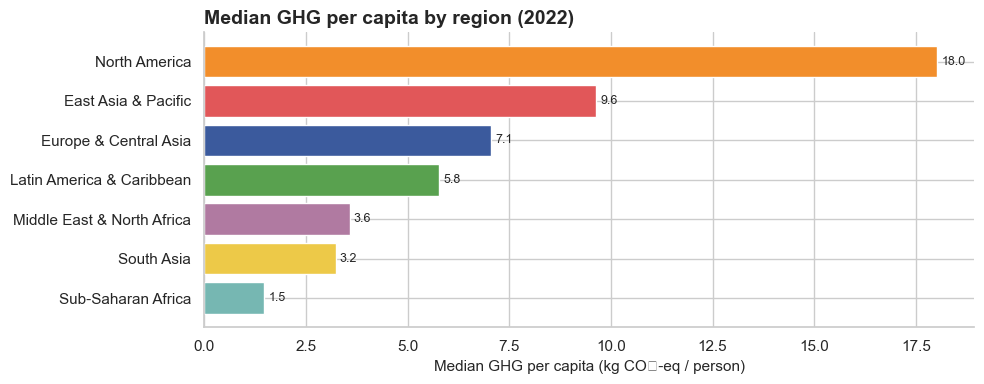

In [ ]:
latest_year = 2022
region_med = (
    df_panel[df_panel['year'] == latest_year]
    .groupby('region')['ghg_per_capita']
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    region_med.index, region_med.values,
    color=[region_colors.get(r, '#999') for r in region_med.index]
)
for bar, val in zip(bars, region_med.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Median GHG per capita (kg CO₂-eq / person)')
ax.set_title(f'Median GHG per capita by region ({latest_year})',
             fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

### 10.2  Do wealthier countries emit more per capita?

There is a clear positive relationship between income and emissions, but it is noisy. Some rich countries emit far less than the trend predicts; some middle-income ones emit more. These outliers, combined with regional colour-coding, motivate a bubble scatter as the core analytical viz → **viz 02**.

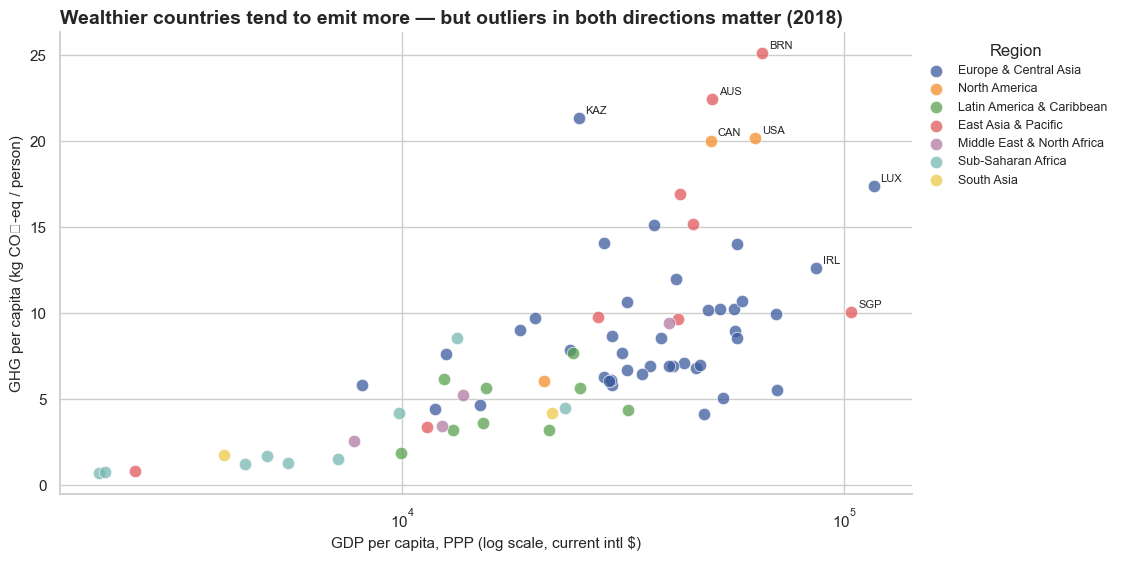

In [37]:
data_2018 = df_panel[df_panel['year'] == 2018].dropna(
    subset=['gdp_per_capita_ppp', 'ghg_per_capita'])

fig, ax = plt.subplots(figsize=(11, 6))
for region, color in region_colors.items():
    sub = data_2018[data_2018['region'] == region]
    ax.scatter(sub['gdp_per_capita_ppp'], sub['ghg_per_capita'],
               c=color, label=region, alpha=0.75, s=80,
               edgecolors='white', linewidths=0.6)

ax.set_xscale('log')

annots = pd.concat([
    data_2018.nlargest(5, 'ghg_per_capita'),
    data_2018.nlargest(3, 'gdp_per_capita_ppp')
]).drop_duplicates()
for _, row in annots.iterrows():
    ax.annotate(row['iso3'],
                (row['gdp_per_capita_ppp'], row['ghg_per_capita']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('GDP per capita, PPP (log scale, current intl $)')
ax.set_ylabel('GHG per capita (kg CO₂-eq / person)')
ax.set_title(
    'Wealthier countries tend to emit more — but outliers in both directions matter (2018)',
    fontweight='bold', loc='left')
ax.legend(title='Region', fontsize=9, frameon=False, bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)

### 10.3  Which countries improved or worsened from 2014 to 2023?

Most countries in the sample reduced per-capita emissions over the decade, but the spread is large: some cut by over 50 %, others increased by 20 %. The divergence between improvers and backsliders motivates a slope chart that shows individual country trajectories → **viz 03**.

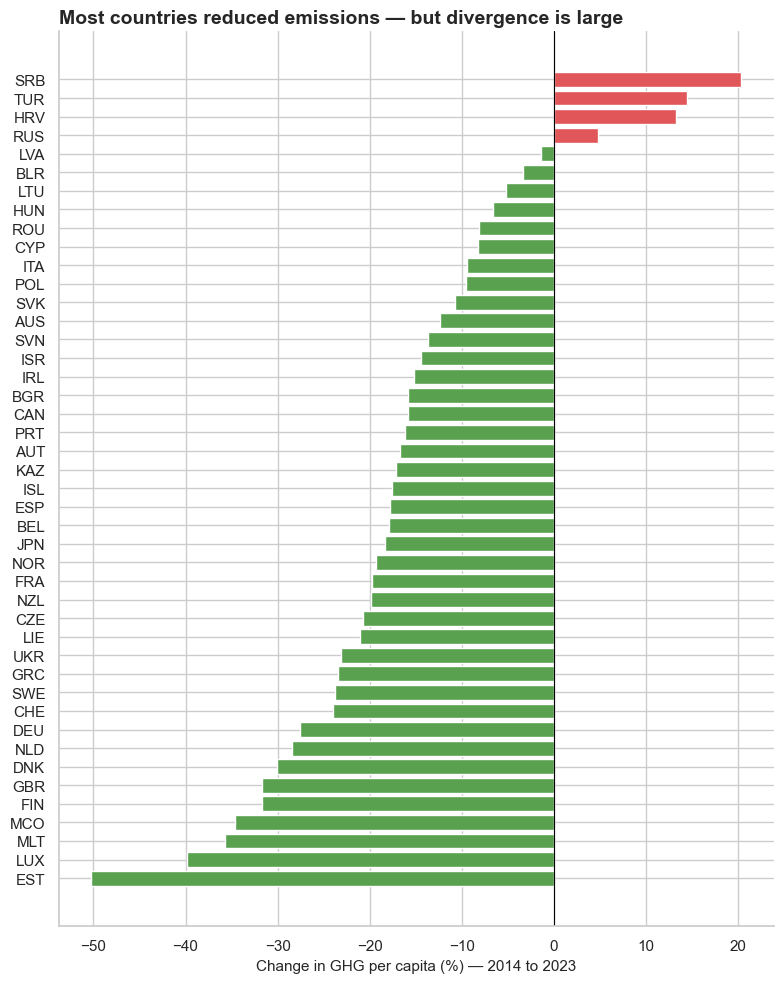

In [ ]:
slope_sorted = df_slope.sort_values('ghg_change_pct')
bar_colors = ['#59a14f' if v < 0 else '#e15759'
              for v in slope_sorted['ghg_change_pct']]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(slope_sorted['iso3'], slope_sorted['ghg_change_pct'],
        color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in GHG per capita (%) — 2014 to 2023')
ax.set_title('Most countries reduced emissions — but divergence is large',
             fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

### 10.4  Does a higher renewable energy share mean lower emissions?

The negative relationship is real but noisy: some high-renewable countries still emit a lot (often because traditional biomass inflates the renewable share), while some low-renewable ones emit relatively little. This ambiguity motivates a diverging dot plot that simultaneously ranks countries by GHG and encodes renewable share → **viz 04**.

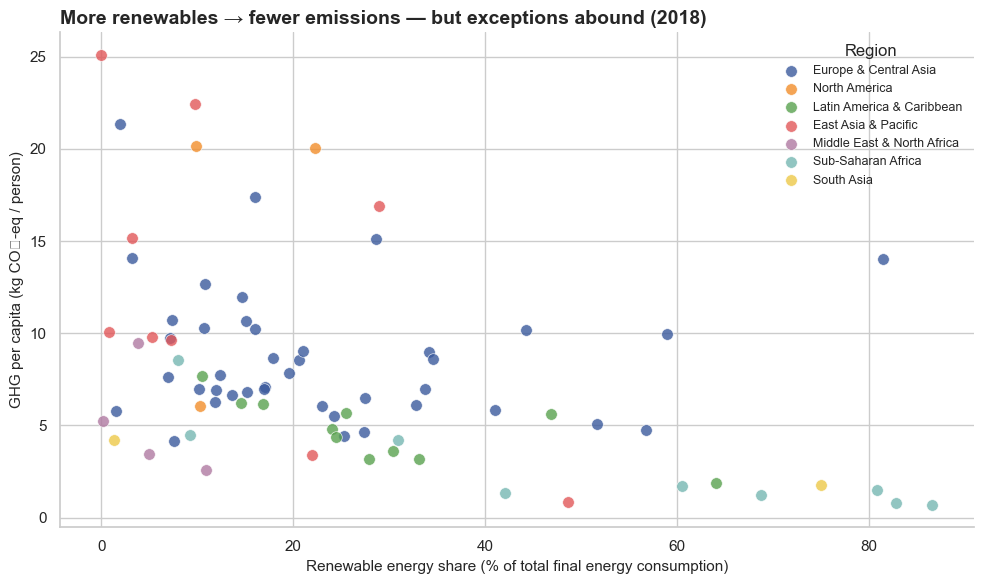

In [ ]:
data_plot = df_panel[df_panel['year'] == 2018].dropna(
    subset=['renewable_pct', 'ghg_per_capita'])

fig, ax = plt.subplots(figsize=(10, 6))
for region, color in region_colors.items():
    sub = data_plot[data_plot['region'] == region]
    ax.scatter(sub['renewable_pct'], sub['ghg_per_capita'],
               c=color, label=region, alpha=0.8, s=70,
               edgecolors='white', linewidths=0.5)

ax.set_xlabel('Renewable energy share (% of total final energy consumption)')
ax.set_ylabel('GHG per capita (kg CO₂-eq / person)')
ax.set_title('More renewables → fewer emissions — but exceptions abound (2018)',
             fontweight='bold', loc='left')
ax.legend(title='Region', fontsize=9, frameon=False, bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

### 10.5  Are low-emission countries clean by choice or by necessity?

Two distinct clusters are visible: countries with very low electricity access naturally emit little (energy poverty, not decarbonisation), while others achieve low emissions with near-universal access (genuine green transition). This split is the central insight behind viz 06.

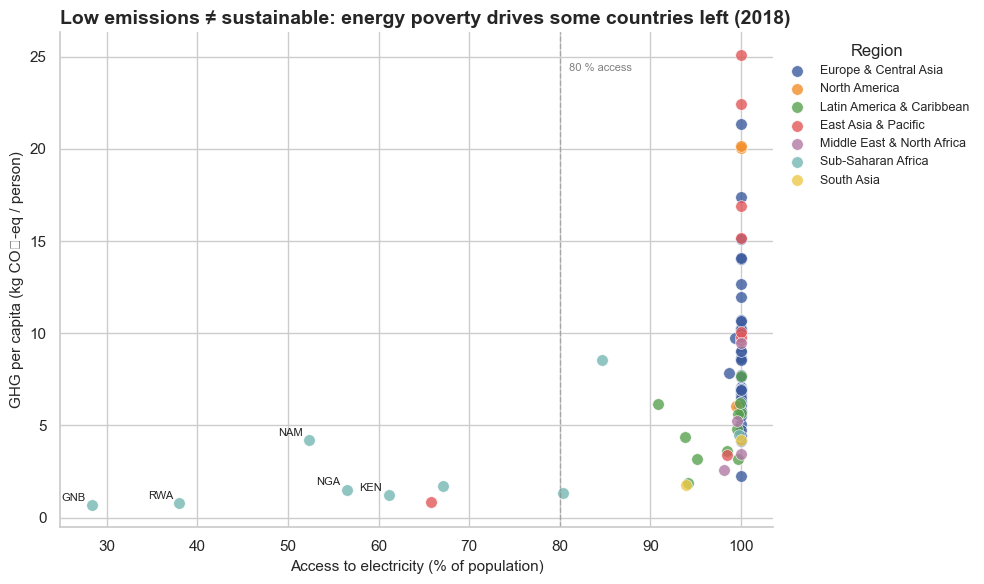

In [ ]:
data_plot = df_panel[df_panel['year'] == 2018].dropna(
    subset=['electricity_access_pct', 'ghg_per_capita'])

fig, ax = plt.subplots(figsize=(10, 6))
for region, color in region_colors.items():
    sub = data_plot[data_plot['region'] == region]
    ax.scatter(sub['electricity_access_pct'], sub['ghg_per_capita'],
               c=color, label=region, alpha=0.8, s=70,
               edgecolors='white', linewidths=0.5)

for _, row in data_plot.nsmallest(5, 'electricity_access_pct').iterrows():
    ax.annotate(row['iso3'],
                (row['electricity_access_pct'], row['ghg_per_capita']),
                fontsize=8, xytext=(-22, 3), textcoords='offset points')

ax.axvline(80, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(81, ax.get_ylim()[1] * 0.92, '80 % access', fontsize=8, color='gray')

ax.set_xlabel('Access to electricity (% of population)')
ax.set_ylabel('GHG per capita (kg CO₂-eq / person)')
ax.set_title(
    'Low emissions ≠ sustainable: energy poverty drives some countries left (2018)',
    fontweight='bold', loc='left')
ax.legend(title='Region', fontsize=9, frameon=False, bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

### 10.6  No single variable explains a country's full profile

The four key variables are partially correlated but each adds independent signal. The heatmap shows no dominant driver; the normalised bar chart shows that countries with similar GHG levels can look radically different across income, renewables, and electricity access. This multi-dimensionality motivates the country profile card (viz 05) and the radial fingerprint (viz 07).

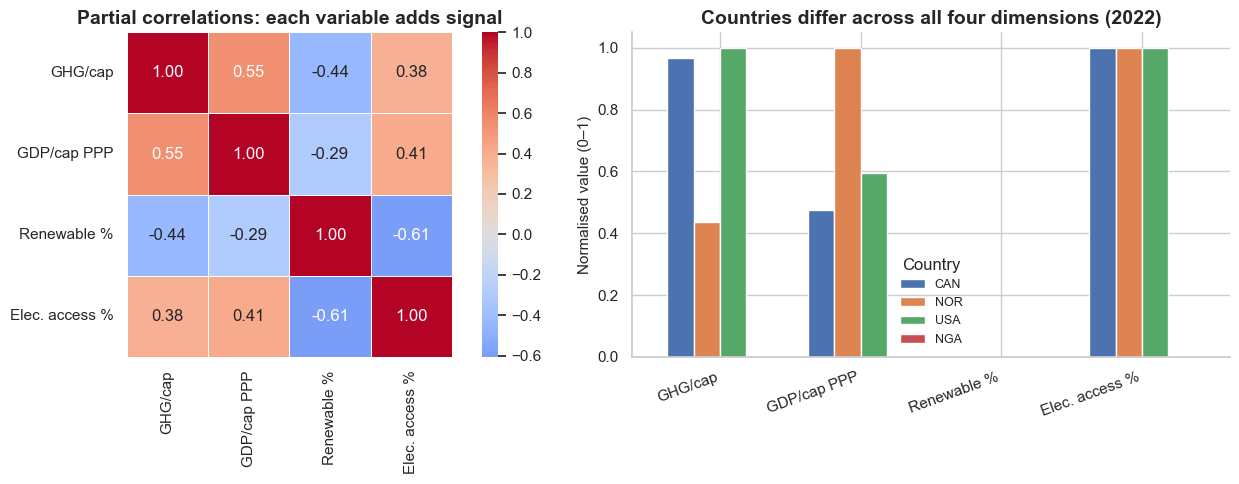

In [41]:
key_vars   = ['ghg_per_capita', 'gdp_per_capita_ppp',
              'renewable_pct', 'electricity_access_pct']
var_labels = ['GHG/cap', 'GDP/cap PPP', 'Renewable %', 'Elec. access %']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correlation heatmap
corr = df_panel[key_vars].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5,
            xticklabels=var_labels, yticklabels=var_labels)
axes[0].set_title('Partial correlations: each variable adds signal',
                  fontweight='bold')

# Right: normalised profiles for 6 representative countries (2022)
sample = ['USA', 'NOR', 'CHN', 'IND', 'NGA', 'CAN']
cp = (df_panel[(df_panel['iso3'].isin(sample)) & (df_panel['year'] == 2022)]
      .set_index('iso3')[key_vars])
cp_norm = (cp - cp.min()) / (cp.max() - cp.min())
cp_norm.T.plot(kind='bar', ax=axes[1], width=0.75)
axes[1].set_xticklabels(var_labels, rotation=20, ha='right')
axes[1].set_title('Countries differ across all four dimensions (2022)',
                  fontweight='bold')
axes[1].set_ylabel('Normalised value (0–1)')
axes[1].legend(title='Country', fontsize=9, frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()

### 10.7  Does the choice of metric flip the narrative?

Per-capita and absolute-total rankings produce almost entirely opposite top-10 lists: small wealthy countries dominate per capita; large populous ones dominate in absolute terms. The same dataset, framed differently, tells two incompatible stories: the core insight behind the white hat / black hat decision → **viz 08**.


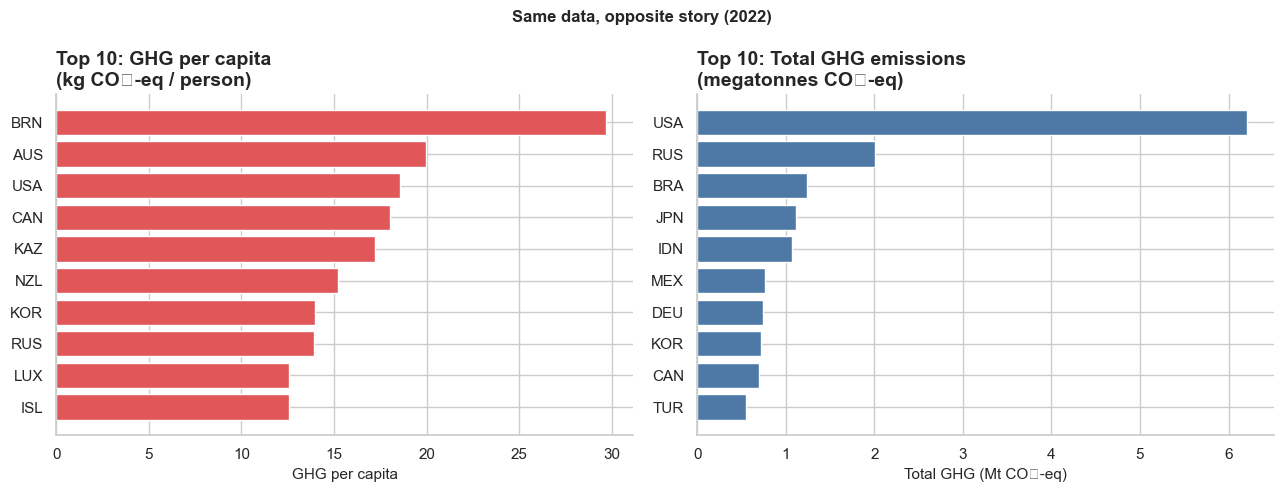

In [ ]:
year = 2022
data_yr = df_panel[df_panel['year'] == year].dropna(
    subset=['ghg_per_capita', 'ghg_total_mt'])

top_cap = data_yr.nlargest(10, 'ghg_per_capita').sort_values('ghg_per_capita')
top_abs = data_yr.nlargest(10, 'ghg_total_mt').sort_values('ghg_total_mt')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_cap['iso3'], top_cap['ghg_per_capita'], color='#e15759')
axes[0].set_title('Top 10: GHG per capita\n(kg CO₂-eq / person)',
                  fontweight='bold', loc='left')
axes[0].set_xlabel('GHG per capita')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(top_abs['iso3'], top_abs['ghg_total_mt'], color='#4e79a7')
axes[1].set_title('Top 10: Total GHG emissions\n(megatonnes CO₂-eq)',
                  fontweight='bold', loc='left')
axes[1].set_xlabel('Total GHG (Mt CO₂-eq)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle(f'Same data, opposite story ({year})', fontsize=12, fontweight='bold')
plt.tight_layout()

## 11. Limitations & Bias Summary

| Issue | Detail | Impact on Analysis |
|-------|--------|--------------------|
| **Temporal mismatch** | World Bank data ends at 2025; OECD GHG runs to 2023. The full 3-dataset panel is limited to 2014–2023. | All visualizations are limited to 2014–2023. |
| **Late-period GHG coverage drops** | The GHG-only dataset has much thinner coverage by 2023 than in earlier years. | Regional averages and endpoint comparisons may reflect changing sample composition as well as real emissions change. |
| **Geographic coverage** | The joined panel includes about **90 countries**; Sub-Saharan Africa and small states remain underrepresented. | Core findings should not be generalized too confidently to the Global South as a whole. |
| **LULUCF exclusion** | OECD GHG data excludes Land Use, Land Use Change and Forestry emissions by design (`MEASURE = '_T'`). | Net emissions of countries with heavy deforestation may be underestimated. |
| **Region variable constructed** | The `region` column is manually mapped from World Bank country metadata rather than taken directly from raw files. | Any mapping error propagates to all regional summaries. |
| **Renewable energy definition** | World Bank `renewable_pct` includes traditional biomass, which can reflect energy poverty rather than a clean transition. | Some low-income countries may appear renewable-heavy for the wrong reason. |
| **Correlation != causation** | The project identifies empirical patterns only; no causal model is estimated. | Findings must be framed as associations rather than effects. |

## 12. Data Integration Summary

### 12.1 From raw sources to final datasets

Five inputs feed the two output files. The join is **GHG-anchored**: OECD GHG provides the country-year skeleton; the other sources are left-joined onto it.

| Raw source | Key variables contributed | Join key |
|---|---|---|
| `OECD.csv` | `iso3`, `country_name_ghg`, `year`, `ghg_per_capita` | anchor |
| `economy-and-growth-2025.csv` | `gdp_per_capita_ppp` | `iso3 × year` |
| `energy-and-mining-2025.csv` | `renewable_pct`, `electricity_access_pct`, `fossil_fuel_pct` | `iso3 × year` |
| `population-2025.csv` | `population`, `ghg_total_mt` | `iso3 × year` |
| WB region lookup (manual) | `region` | `iso3` |

---

### 12.2 Variable coverage across the two output files

`✓` = present in that file   `—` = not present

| Variable | Source | `df_panel` | `df_slope` |
|---|---|:---:|:---:|
| `iso3` | OECD GHG | ✓ | ✓ |
| `country_name_ghg` | OECD GHG | ✓ | ✓ |
| `year` | OECD GHG | ✓ | — |
| `ghg_per_capita` | OECD GHG | ✓ | — |
| `region` | WB metadata | ✓ | ✓ |
| `gdp_per_capita_ppp` | WB Economy | ✓ | — |
| `renewable_pct` | WB Energy | ✓ | — |
| `electricity_access_pct` | WB Energy | ✓ | — |
| `fossil_fuel_pct` | WB Energy | ✓ | — |
| `population` | WB Population | ✓ | — |
| `ghg_total_mt` | Derived (GHG × population) | ✓ | — |
| `ghg_2014` | Derived (OECD) | — | ✓ |
| `ghg_2023` | Derived (OECD) | — | ✓ |
| `ghg_change_pct` | Derived (OECD) | — | ✓ |
| `ghg_change_abs` | Derived (OECD) | — | ✓ |

---

### 12.3 Which dataset feeds each visualization

| Viz | Title | File | Key variables |
|---|---|---|---|
| 01 | Choropleth map | `df_panel.csv` | `iso3`, `year`, `ghg_per_capita`, `region` |
| 02 | Bubble scatter GDP vs GHG | `df_panel.csv` | `gdp_per_capita_ppp`, `ghg_per_capita`, `region`, `year` |
| 03 | Slope chart 2014→2023 | `df_slope.csv` | `ghg_2014`, `ghg_2023`, `ghg_change_pct`, `region` |
| 04 | Diverging dot plot GHG vs renewables | `df_panel.csv` | `ghg_per_capita`, `renewable_pct`, `region` |
| 05 | Country profile card | `df_panel.csv` | all key variables, `country_name_ghg` |
| 06 | Scatter electricity access vs GHG | `df_panel.csv` | `electricity_access_pct`, `ghg_per_capita`, `region` |
| 07 ★ | Radial Emission Fingerprint | `df_panel.csv` | `ghg_per_capita`, `gdp_per_capita_ppp`, `renewable_pct`, `electricity_access_pct` |
| 08 | White hat / Black hat maps | `df_panel.csv` | `iso3`, `ghg_per_capita`, `ghg_total_mt` |

## 13. Visualization Plan


| Viz | Title | Tool | Input file | Key variables | Analytical question |
|-----|-------|------|------------|---------------|---------------------|
| 01 | Choropleth map | Power BI | `df_panel.csv` | `iso3`, `year`, `ghg_per_capita`, `region` | Where are emissions highest, and how has the global distribution shifted year by year from 2014 to 2020? Serves as the spatial entry point and cross-filtering hub for the whole dashboard. |
| 02 | Bubble scatter GDP vs GHG | Power BI | `df_panel.csv` | `gdp_per_capita_ppp`, `ghg_per_capita`, `region`, `year` | Do wealthier countries systematically emit more per capita? Which countries break the expected pattern, that is high income but low emissions, or low income but high emissions? |
| 03 | Slope chart 2014→2023 | Python (Plotly) | `df_slope.csv` | `ghg_2014`, `ghg_2023`, `ghg_change_pct`, `region` | Which countries have reduced their per-capita emissions the most over the decade, and which have worsened? Does improvement cluster by region or income level? |
| 04 | Diverging dot plot GHG vs renewables | Python (Altair) | `df_panel.csv` | `ghg_per_capita`, `renewable_pct`, `region` | Is there a clean inverse relationship between renewable energy share and emissions? Do low-emission countries tend to have high renewables, or are other factors at play? |
| 05 | Country profile card | JavaScript | `df_panel.csv` | all key variables, `country_name_ghg` | How does any single country compare to its regional and global averages across all four key dimensions simultaneously? Supports the deep-profile task for non-expert users. |
| 06 | Scatter electricity access vs GHG | Power BI | `df_panel.csv` | `electricity_access_pct`, `ghg_per_capita`, `region` | Are low-emission countries truly "clean", or are their low figures explained by limited electricity access and energy poverty rather than deliberate decarbonization? |
| 07 ★ | Radial Emission Fingerprint | D3.js | `df_panel.csv` | `ghg_per_capita`, `gdp_per_capita_ppp`, `renewable_pct`, `electricity_access_pct` | What is the full four-variable "emissions profile" of a country, and how do up to four countries compare when all dimensions are shown simultaneously on a single radial form? |
| 08 | White hat / Black hat maps | Power BI | `df_panel.csv` | `iso3`, `ghg_per_capita` (per capita vs absolute) | How does the choice of metric, per capita vs total absolute emissions, produce opposite narratives from the same data, making small rich countries appear as villains or heroes depending on framing? |